In [2]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
import re

In [5]:
data = np.memmap("test.npy")

In [10]:
len(data) / 1024**3

3.96807861328125

In [4]:
root_dir = os.path.dirname(os.path.abspath(os.getcwd()))
os.chdir(root_dir)
print(os.getcwd())

/home/iwatts/catastrophic-forgetting


In [3]:
results_dir = "results/"

In [24]:
try:
    RESULTS = json.load(os.path.join(results_dir, 'all_results.json'))
    print("Loading results...")
except:
    RESULTS = dict()   
    print("Could not find results, initializing empty dictionary")   

Could not find results, initializing empty dictionary


In [25]:
TASKNAME_MAP = {
    "c4_val": "eval-data_perplexity_v3_small_gptneox20b_c4_en_val_part-0-00000",
    "starcoder_val": "preprocessed_starcoder_v0_decontaminated_doc_only_gpt-neox-olmo-dolma-v1_5_part-00-00001"
}

In [26]:
os.listdir(results_dir)

['sam-ablation', 'sgd-gridsearch.png', 'sgd-gridsearch', 'sam-overtraining']

In [27]:
for project in os.listdir(results_dir):
    if project != "sam-ablation" and project != "sgd-gridsearch":
        continue

    project_results = list()
    project_dir = os.path.join(results_dir, project)
    for file in os.listdir(project_dir):

        fname = os.path.join(project_dir, file)
        with open(fname, 'r') as f:
            data = json.load(f)

        fname = fname.removesuffix("-eval.json")

        # Detect run type by "CPT" in the filename
        is_cpt = 'CPT' in fname
        run_type = "cpt" if is_cpt else "pretrain"

        # Always get tk<B>
        token_match = re.search(r'tk(\d+)B', fname)
        token = token_match.group(1) if token_match else "unknown"
        if token != "unknown":
            try:
                token = int(token)
            except Exception:
                raise ValueError("Unable to convert to Int")
        else:
            raise ValueError("Unable to Parse")

        # Get the optimizer (can be sam, adamw, lionw, sam_adamw, sam_sgd)
        optimizer_match = re.search(r'tk\d+B-([a-zA-Z0-9_]+)-lr', fname)
        optimizer_raw = optimizer_match.group(1) if optimizer_match else "unknown"

        # Handle sam_adamw and sam_sgd specially
        if optimizer_raw in ("sam_adamw", "sam_sgd"):
            optimizer = "sam"
            base_optimizer = optimizer_raw.split("_")[1]
            
            # Properly extract rho after "-rho", e.g.: "...-bs256-rho1e-1-"
            rho_match = re.search(r'-rho([0-9eE\+\-\.]+)', fname)
            if not rho_match:
                # fallback: some files may omit '-rho', to maintain old behavior if necessary
                rho_match = re.search(r'-bs256-([0-9eE\+\-\.]+)-', fname)
            rho = rho_match.group(1) if rho_match else "unknown"

            if rho != "unknown":
                rho_cleaned = re.sub(r'[^0-9eE\+\-\.]+$', '', rho)
                rho_cleaned = rho_cleaned.rstrip('-')
                try:
                    rho_val = float(rho_cleaned)
                except Exception:
                    raise ValueError(f"Unable to convert rho to float: {rho_cleaned!r}")
            else:
                raise ValueError("Unable to Parse rho")
        else:
            optimizer = optimizer_raw
            base_optimizer = None
            rho_val = None

        # Always get pretrain_lr (after the optimizer)
        pretrain_lr_match = re.search(rf'{optimizer_raw}-lr([0-9eE\+\-\.]+)', fname)
        pretrain_lr = pretrain_lr_match.group(1) if pretrain_lr_match else "unknown"
        if pretrain_lr != "unknown":
            pretrain_lr_cleaned = re.sub(r'[^0-9eE\+\-\.]+$', '', pretrain_lr)
            pretrain_lr_cleaned = pretrain_lr_cleaned.rstrip('-')
            try:
                pretrain_lr = float(pretrain_lr_cleaned)
            except Exception:
                raise ValueError(f"Unable to convert to Float: {pretrain_lr_cleaned!r}")
        else:
            raise ValueError("Unable to Parse")

        # Always get pretrain_wd (right after pretrain_lr)
        pretrain_wd_match = re.search(rf'{optimizer_raw}-lr[0-9eE\+\-\.]+-wd([0-9eE\+\-\.]+)', fname)
        pretrain_wd = pretrain_wd_match.group(1) if pretrain_wd_match else "unknown"
        if pretrain_wd != "unknown":
            pretrain_wd_cleaned = re.sub(r'[^0-9eE\+\-\.]+$', '', pretrain_wd)
            pretrain_wd_cleaned = pretrain_wd_cleaned.rstrip('-')
            try:
                pretrain_wd = float(pretrain_wd_cleaned)
            except Exception:
                raise ValueError(f"Unable to convert to Float: {pretrain_wd_cleaned!r}")
        else:
            raise ValueError("Unable to Parse")

        # Default cpt values
        cpt_lr, cpt_wd = None, None
        if is_cpt:
            cpt_lr_match = re.search(r'CPT-starcoder-lr([0-9eE\+\-\.]+)', fname)
            cpt_lr = cpt_lr_match.group(1) if cpt_lr_match else "unknown"
            if cpt_lr != "unknown":
                cpt_lr_cleaned = re.sub(r'[^0-9eE\+\-\.]+$', '', cpt_lr)
                cpt_lr_cleaned = cpt_lr_cleaned.rstrip('-')
                try:
                    cpt_lr = float(cpt_lr_cleaned)
                except Exception:
                    raise ValueError(f"Unable to convert to Float: {cpt_lr_cleaned!r}")
            else:
                raise ValueError("Unable to Parse")

            cpt_wd_match = re.search(r'CPT-starcoder-lr[0-9eE\+\-\.]+-wd([0-9eE\+\-\.]+)', fname)
            cpt_wd = cpt_wd_match.group(1) if cpt_wd_match else "unknown"
            if cpt_wd != "unknown":
                cpt_wd_cleaned = re.sub(r'[^0-9eE\+\-\.]+$', '', cpt_wd)
                cpt_wd_cleaned = cpt_wd_cleaned.rstrip('-')
                try:
                    cpt_wd = float(cpt_wd_cleaned)
                except Exception:
                    raise ValueError(f"Unable to convert to Float: {cpt_wd_cleaned!r}")
            else:
                raise ValueError("Unable to Parse")

        run_info = {
            "run_type": run_type,
            "token": token,
            "optimizer": optimizer,
            "pretrain_lr": pretrain_lr,
            "pretrain_wd": pretrain_wd,
            "c4_val": data[TASKNAME_MAP["c4_val"]],
            "starcoder_val": data[TASKNAME_MAP["starcoder_val"]],
        }
        if base_optimizer is not None:
            run_info["base_optimizer"] = base_optimizer
        if rho_val is not None:
            run_info["rho"] = rho_val
        if is_cpt:
            run_info["cpt_lr"] = cpt_lr
            run_info["cpt_wd"] = cpt_wd
        
        project_results.append(run_info)
    
    RESULTS[project] = project_results


In [19]:
RESULTS.keys()

dict_keys(['sam-ablation', 'sgd-gridsearch'])

In [20]:
RESULTS["sgd-gridsearch"][0]

{'run_type': 'cpt',
 'token': 8,
 'optimizer': 'adamw',
 'pretrain_lr': 0.0003,
 'pretrain_wd': 0.1,
 'c4_val': 4.01952028866088,
 'starcoder_val': 3.4747816469515826,
 'cpt_lr': 4e-05,
 'cpt_wd': 0.1}

### SGD Grid-Search

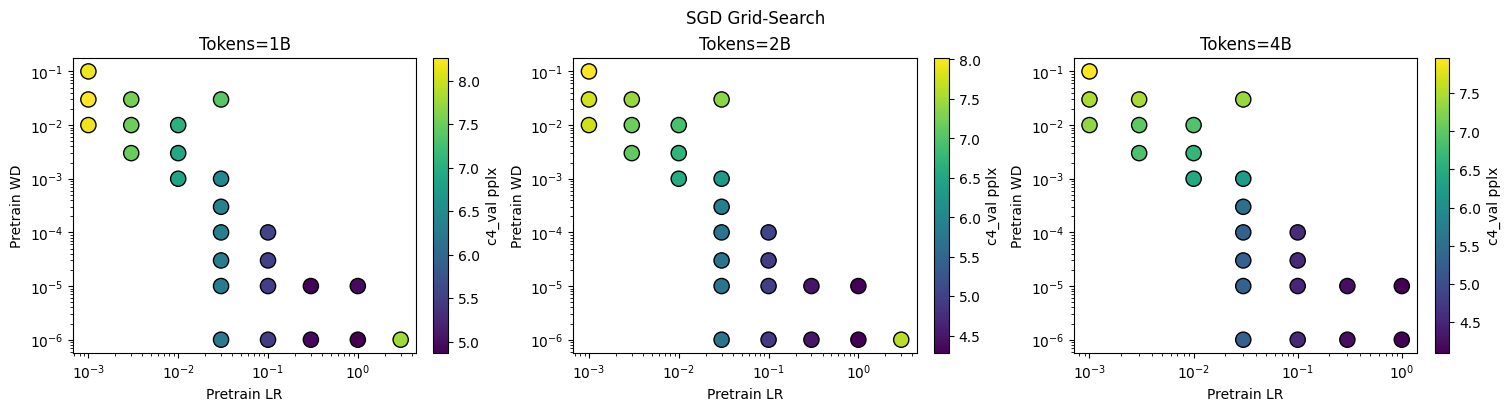

In [ ]:
# Filter for "pretrain" run_type and "sgd" optimizer
sgd_pretrain_runs = [r for r in RESULTS["sgd-gridsearch"] if r["run_type"] == "pretrain" and r["optimizer"] == "sgd"]

# Tokens for which to plot
tokens_to_plot = [1, 2, 4]

fig, axs = plt.subplots(1, len(tokens_to_plot), figsize=(5 * len(tokens_to_plot), 4), constrained_layout=True)
if len(tokens_to_plot) == 1:
    axs = [axs]

for i, token in enumerate(tokens_to_plot):
    runs = [r for r in sgd_pretrain_runs if r["token"] == token]

    if not runs:
        axs[i].set_title(f"token={token} (no runs found)")
        axs[i].set_xlabel("pretrain_lr")
        axs[i].set_ylabel("pretrain_wd")
        continue

    # If wd == 0, set it to 1e-6
    for r in runs:
        if r["pretrain_wd"] == 0:
            r["pretrain_wd"] = 1e-6

    # Prepare arrays for scatter
    x = np.array([r["pretrain_lr"] for r in runs])
    y = np.array([r["pretrain_wd"] for r in runs])
    z = np.array([r["c4_val"] for r in runs])

    scatter = axs[i].scatter(x, y, c=z, cmap="viridis", s=120, edgecolor='black')
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].set_title(f"Tokens={token}B")
    axs[i].set_xlabel("Pretrain LR")
    axs[i].set_ylabel("Pretrain WD")
    cbar = fig.colorbar(scatter, ax=axs[i], label="c4_val pplx")
    
    # Customize y-axis tick labels: rep

    # # Overlay values
    # for xi, yi, val in zip(x, y, z):
    #     axs[i].text(xi, yi, f"{val:.2f}", ha="center", va="center", color="white", fontsize=9)

plt.suptitle("SGD Grid-Search")
plt.savefig(os.path.join(results_dir, "sgd-gridsearch.png"))
plt.show()



In [129]:
RESULTS["sam-ablation"][0]

{'run_type': 'pretrain',
 'token': 4,
 'optimizer': 'sam',
 'pretrain_lr': 1.0,
 'pretrain_wd': 1e-05,
 'c4_val': 4.156254130085608,
 'starcoder_val': 4.924695252121012,
 'base_optimizer': 'sgd',
 'rho': 0.1}

### Rho Ablation Plot

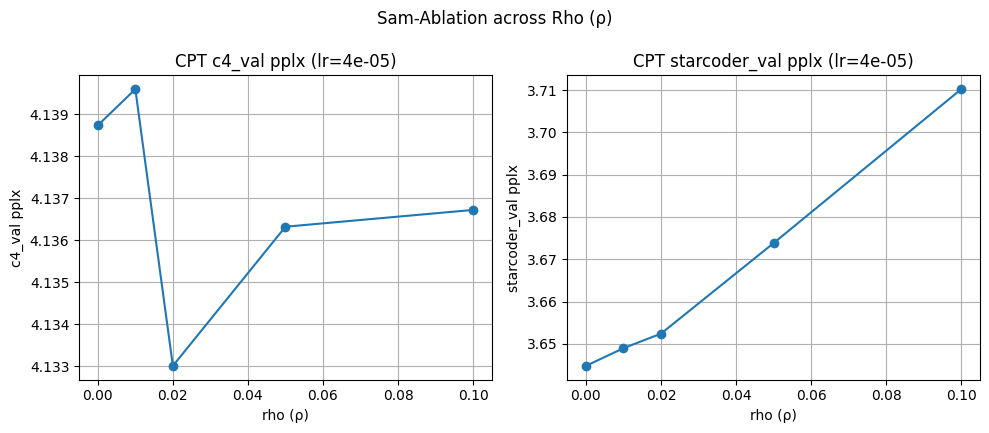

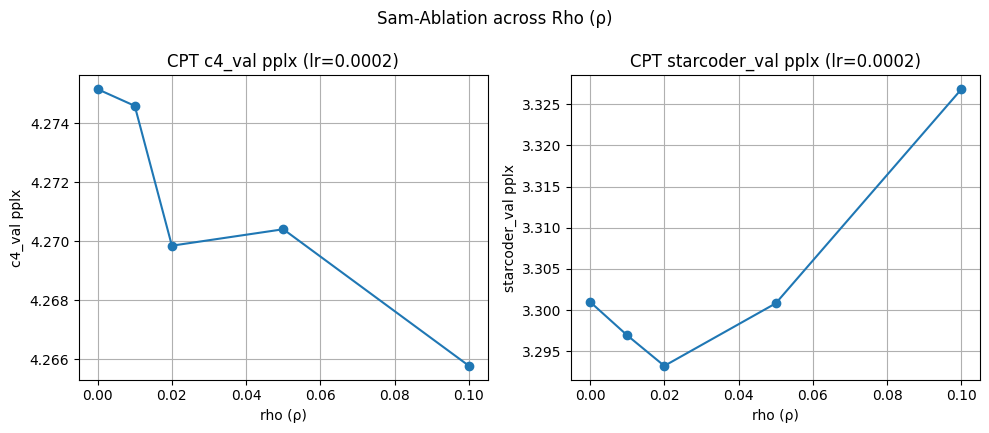

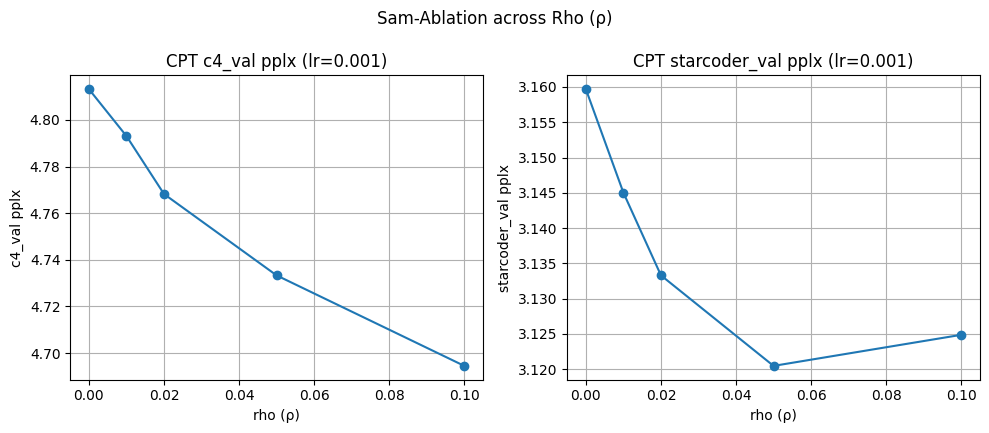

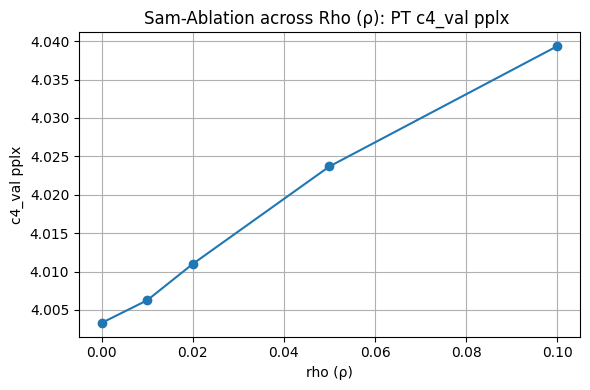

In [38]:
# Helper: filter, sort, and group runs by keys
def group_by(runs, key):
    groups = {}
    for r in runs:
        v = r[key]
        if v not in groups:
            groups[v] = []
        groups[v].append(r)
    return groups

# --- prepare data for cpt ---
runs = [r for r in RESULTS["sam-ablation"] if (r.get('optimizer')=="sam" and r.get('base_optimizer', None)=="adamw" and r.get('token')==4)]
runs_cpt = [r for r in runs if r.get('run_type') == 'cpt']
runs_pretrain = [r for r in runs if r.get('run_type') == 'pretrain']

# ---- CPT: make separate plots for each cpt_lr ----
if runs_cpt:
    cpt_lr_groups = group_by(runs_cpt, "cpt_lr")
    for cpt_lr, group in sorted(cpt_lr_groups.items()):
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        for metric, ax in zip(["c4_val", "starcoder_val"], axs):
            group_sorted = sorted(group, key=lambda r: float(r["rho"]))
            rhos = [float(r["rho"]) for r in group_sorted]
            vals = [r[metric] for r in group_sorted]
            ax.plot(rhos, vals, marker='o')
            ax.set_xlabel("rho (ρ)")
            ax.set_ylabel(metric+" pplx")
            ax.set_title(f"CPT {metric} pplx (lr={cpt_lr})")
            ax.grid(True)
        
        
        plt.tight_layout()
        plt.suptitle(f"Sam-Ablation across Rho (ρ)", y=1.07)
        plt.savefig(os.path.join(results_dir, f"cpt_sam_ablation_lr{cpt_lr}.png"))
        plt.show()

# ---- Pretrain: plot c4_val across rho ----
if runs_pretrain:
    plt.figure(figsize=(6,4))
    # Only show unique rhos
    group_sorted = sorted(runs_pretrain, key=lambda r: float(r["rho"]))
    rhos = [float(r["rho"]) for r in group_sorted]
    vals = [r["c4_val"] for r in group_sorted]
    plt.plot(rhos, vals, marker='o')
    plt.xlabel('rho (ρ)')
    plt.ylabel('c4_val pplx')
    plt.grid((True))
    plt.title('Sam-Ablation across Rho (ρ): PT c4_val pplx ')
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, f"pt_sam_ablation.png"))
    plt.show()


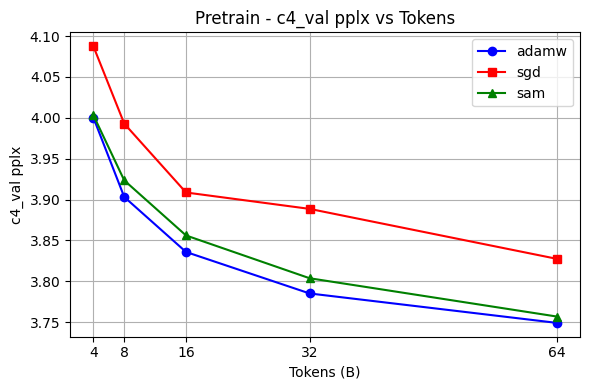

In [50]:
from calendar import c


tokens_list = [4, 8, 16, 32, 64]

# --- sgd-gridsearch, optimizer=adamw and lionw ---
runs_gridsearch = [r for r in RESULTS["sgd-gridsearch"] if r.get("run_type") == "pretrain" and r.get("token") in tokens_list]

# 1. optimizer = adamw
adamw_runs = [r for r in runs_gridsearch if r.get("optimizer") == "adamw"]
adamw_points = []
for t in tokens_list:
    candidates = [r for r in adamw_runs if r.get("token") == t]
    if candidates:
        # Pick the one with the lowest c4_val (just a choice if multiple)
        best = min(candidates, key=lambda x: x["c4_val"])
        adamw_points.append((t, best["c4_val"]))
    else:
        adamw_points.append((t, None))  # Possibly missing

adamw_tokens, adamw_c4_vals = zip(*[(t, v) for t, v in adamw_points if v is not None])

# 1b. optimizer = lionw
# lionw_runs = [r for r in runs_gridsearch if r.get("optimizer") == "lionw"]
# lionw_points = []
# for t in tokens_list:
#     candidates = [r for r in lionw_runs if r.get("token") == t]
#     if candidates:
#         # Pick the one with the lowest c4_val (just a choice if multiple)
#         best = min(candidates, key=lambda x: x["c4_val"])
#         lionw_points.append((t, best["c4_val"]))
#     else:
#         lionw_points.append((t, None))  # Possibly missing

# lionw_tokens, lionw_c4_vals = zip(*[(t, v) for t, v in lionw_points if v is not None])

# 2. optimizer = sgd, pretrain_wd=1e-5, lr as per instructions
sgd_runs = [r for r in runs_gridsearch if r.get("optimizer") == "sgd" and (float(r.get("pretrain_wd", -1)) == 1e-5)]
sgd_points = []
for t in tokens_list:
    if t == 64:
        lr_val = 0.5
    else:
        lr_val = 1.0
    # Filter by token and pretrain_lr
    candidates = [
        r for r in sgd_runs
        if r.get("token") == t and (float(r.get("pretrain_lr", -1)) == lr_val)
    ]
    if candidates:
        best = min(candidates, key=lambda x: x["c4_val"])
        sgd_points.append((t, best["c4_val"]))
    else:
        sgd_points.append((t, None))
sgd_tokens, sgd_c4_vals = zip(*[(t, v) for t, v in sgd_points if v is not None])

# 3. sam-ablation: optimizer=sam, base_optimizer=adamw
runs_sam_ablation = [
    r for r in RESULTS["sam-ablation"]
    if (
        r.get("run_type") == "pretrain"
        and r.get("token") in tokens_list
        and r.get("optimizer") == "sam"
        and r.get("base_optimizer", None) == "adamw"
    )
]
# We may have multiple runs per token, pick min c4_val
sam_points = []
for t in tokens_list:
    candidates = [r for r in runs_sam_ablation if r["token"] == t]
    if candidates:
        best = min(candidates, key=lambda x: x["c4_val"])
        sam_points.append((t, best["c4_val"]))
    else:
        sam_points.append((t, None))
sam_tokens, sam_c4_vals = zip(*[(t, v) for t, v in sam_points if v is not None])

# --- Plot ---
plt.figure(figsize=(6,4))
plt.plot(adamw_tokens, adamw_c4_vals, marker='o', label="adamw", color='blue')
# plt.plot(lionw_tokens, lionw_c4_vals, marker='D', label="lionw", color='orange')
plt.plot(sgd_tokens, sgd_c4_vals, marker='s', label="sgd", color='red')
plt.plot(sam_tokens, sam_c4_vals, marker='^', label="sam", color='green')
plt.xlabel("Tokens (B)")
plt.xticks(tokens_list, tokens_list)
plt.ylabel("c4_val pplx")
# plt.xscale('log')
plt.title("Pretrain - c4_val pplx vs Tokens")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, f"optim_pt_pplx.png"))
plt.show()


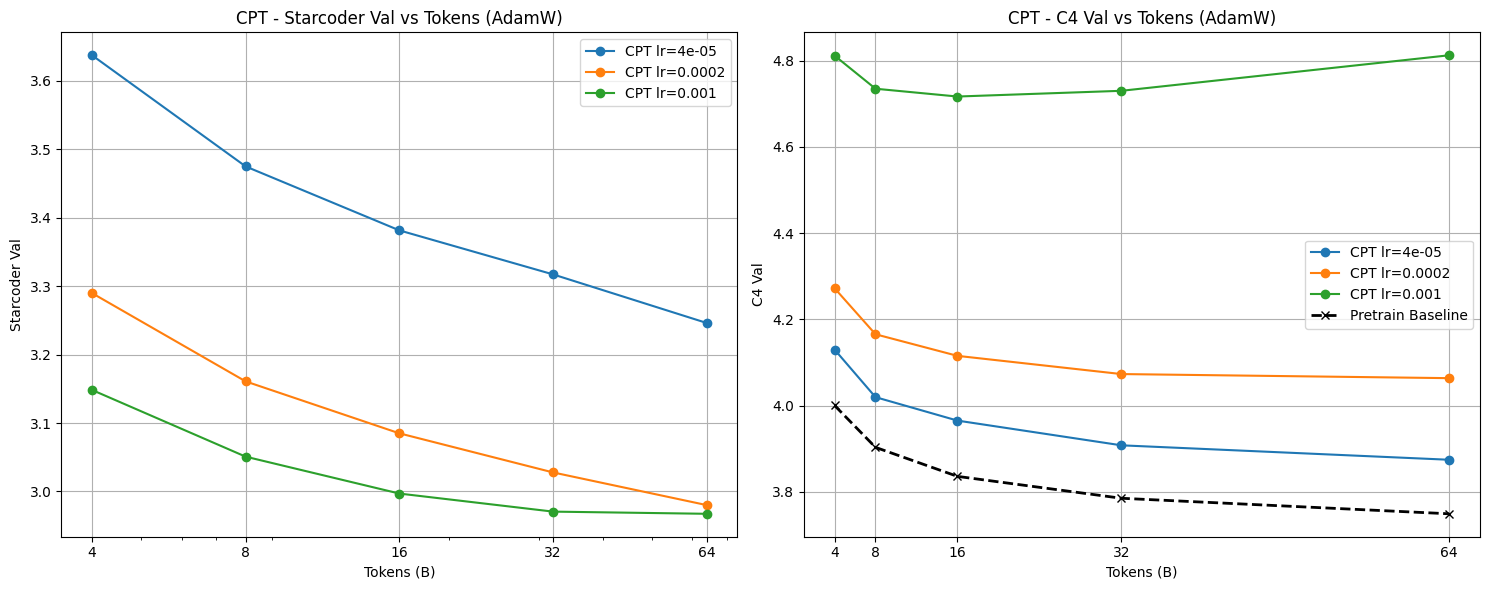

In [143]:
import matplotlib.pyplot as plt

tokens_list = [4, 8, 16, 32, 64]

# Get CPT runs from both datasets
sgd_gridsearch_cpt = [r for r in RESULTS["sgd-gridsearch"] 
                      if r.get("run_type") == "cpt" 
                      and r.get("token") in tokens_list 
                      and r.get("optimizer") == "adamw"]

# sam_ablation_cpt = [r for r in RESULTS["sgd-gridsearch"] 
#                     if r.get("run_type") == "cpt" 
#                     and r.get("token") in tokens_list 
#                     and r.get("optimizer") == "adamw"]

# Combine all CPT runs
all_cpt_runs = sgd_gridsearch_cpt

# Get baseline pretrain runs for c4_val
pretrain_runs = [r for r in RESULTS["sgd-gridsearch"] 
                 if r.get("run_type") == "pretrain" 
                 and r.get("token") in tokens_list 
                 and r.get("optimizer") == "adamw"]

# Get unique CPT learning rates
cpt_lrs = sorted(list(set([r.get("cpt_lr") for r in all_cpt_runs if r.get("cpt_lr") is not None])))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Starcoder validation values
for lr in cpt_lrs:
    starcoder_points = []
    for t in tokens_list:
        candidates = [r for r in all_cpt_runs 
                     if r.get("token") == t and r.get("cpt_lr") == lr]
        if candidates:
            # Pick the one with the best (lowest) starcoder_val
            best = min(candidates, key=lambda x: x.get("starcoder_val", float('inf')))
            starcoder_points.append((t, best["starcoder_val"]))
        else:
            starcoder_points.append((t, None))
    
    starcoder_tokens, starcoder_vals = zip(*[(t, v) for t, v in starcoder_points if v is not None])
    if starcoder_tokens:
        ax1.plot(starcoder_tokens, starcoder_vals, marker='o', label=f'CPT lr={lr}')

ax1.set_xscale('log')
ax1.set_xticks(tokens_list)
ax1.set_xticklabels(tokens_list)
ax1.set_xlabel("Tokens (B)")
ax1.set_ylabel("Starcoder Val")
ax1.set_title("CPT - Starcoder Val vs Tokens (AdamW)")
ax1.legend()
ax1.grid(True)

# Plot 2: C4 validation values with baseline
for lr in cpt_lrs:
    c4_points = []
    for t in tokens_list:
        candidates = [r for r in all_cpt_runs 
                     if r.get("token") == t and r.get("cpt_lr") == lr]
        if candidates:
            # Pick the one with the best (lowest) c4_val
            best = min(candidates, key=lambda x: x.get("c4_val", float('inf')))
            c4_points.append((t, best["c4_val"]))
        else:
            c4_points.append((t, None))
    
    c4_tokens, c4_vals = zip(*[(t, v) for t, v in c4_points if v is not None])
    if c4_tokens:
        ax2.plot(c4_tokens, c4_vals, marker='o', label=f'CPT lr={lr}')

# Add baseline pretrain results
baseline_points = []
for t in tokens_list:
    candidates = [r for r in pretrain_runs if r.get("token") == t]
    if candidates:
        best = min(candidates, key=lambda x: x.get("c4_val", float('inf')))
        baseline_points.append((t, best["c4_val"]))
    else:
        baseline_points.append((t, None))

baseline_tokens, baseline_vals = zip(*[(t, v) for t, v in baseline_points if v is not None])
if baseline_tokens:
    ax2.plot(baseline_tokens, baseline_vals, marker='x', linestyle='--', 
             color='black', linewidth=2, label='Pretrain Baseline')

# ax2.set_xscale('log')
ax2.set_xticks(tokens_list)
ax2.set_xticklabels(tokens_list)
ax2.set_xlabel("Tokens (B)")
ax2.set_ylabel("C4 Val")
ax2.set_title("CPT - C4 Val vs Tokens (AdamW)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

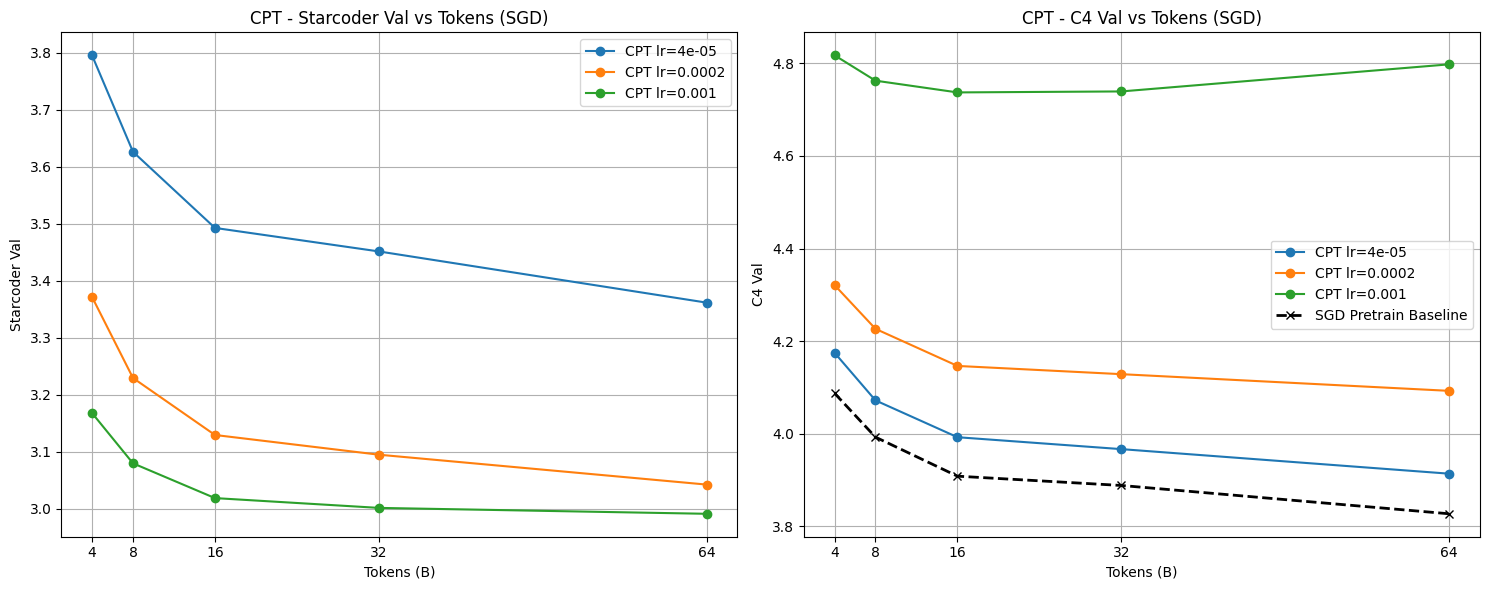

In [136]:
import matplotlib.pyplot as plt

tokens_list = [4, 8, 16, 32, 64]

# Get CPT runs from sgd-gridsearch for SGD optimizer, 
# restrict to cpt runs that used pretrain_lr=1 for token=4,8,16,32 and pretrain_lr=0.5 for token=64
sgd_cpt_runs = []
for r in RESULTS["sgd-gridsearch"]:
    if (
        r.get("run_type") == "cpt"
        and r.get("token") in tokens_list
        and r.get("optimizer") == "sgd"
        and float(r.get("pretrain_wd", -1)) == 1e-5
    ):
        token = r.get("token")
        pretrain_lr = float(r.get("pretrain_lr", -1))
        # For 64 tokens, use lr=0.5; for 4,8,16,32 use lr=1.0
        if (token == 64 and pretrain_lr == 0.5) or (token != 64 and pretrain_lr == 1.0):
            sgd_cpt_runs.append(r)

# Get pretrain runs for SGD baseline with specific lr and wd criteria
sgd_pretrain_runs = []
for r in RESULTS["sgd-gridsearch"]:
    if (
        r.get("run_type") == "pretrain"
        and r.get("token") in tokens_list
        and r.get("optimizer") == "sgd"
        and float(r.get("pretrain_wd", -1)) == 1e-5
    ):
        token = r.get("token")
        pretrain_lr = float(r.get("pretrain_lr", -1))
        # For 64 tokens, use lr=0.5, for others use lr=1.0
        if (token == 64 and pretrain_lr == 0.5) or (token != 64 and pretrain_lr == 1.0):
            sgd_pretrain_runs.append(r)

# Get unique CPT learning rates
cpt_lrs = sorted(list(set([r.get("cpt_lr") for r in sgd_cpt_runs if r.get("cpt_lr") is not None])))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Starcoder validation values
for lr in cpt_lrs:
    starcoder_points = []
    for t in tokens_list:
        candidates = [r for r in sgd_cpt_runs 
                     if r.get("token") == t and r.get("cpt_lr") == lr]
        if candidates:
            # Pick the one with the best (lowest) starcoder_val
            best = min(candidates, key=lambda x: x.get("starcoder_val", float('inf')))
            starcoder_points.append((t, best["starcoder_val"]))
        else:
            starcoder_points.append((t, None))
    
    starcoder_tokens, starcoder_vals = zip(*[(t, v) for t, v in starcoder_points if v is not None])
    if starcoder_tokens:
        ax1.plot(starcoder_tokens, starcoder_vals, marker='o', label=f'CPT lr={lr}')

ax1.set_xticks(tokens_list)
ax1.set_xticklabels(tokens_list)
ax1.set_xlabel("Tokens (B)")
ax1.set_ylabel("Starcoder Val")
ax1.set_title("CPT - Starcoder Val vs Tokens (SGD)")
ax1.legend()
ax1.grid(True)

# Plot 2: C4 validation values with SGD baseline
for lr in cpt_lrs:
    c4_points = []
    for t in tokens_list:
        candidates = [r for r in sgd_cpt_runs 
                     if r.get("token") == t and r.get("cpt_lr") == lr]
        if candidates:
            # Pick the one with the best (lowest) c4_val
            best = min(candidates, key=lambda x: x.get("c4_val", float('inf')))
            c4_points.append((t, best["c4_val"]))
        else:
            c4_points.append((t, None))
    
    c4_tokens, c4_vals = zip(*[(t, v) for t, v in c4_points if v is not None])
    if c4_tokens:
        ax2.plot(c4_tokens, c4_vals, marker='o', label=f'CPT lr={lr}')

# Add SGD baseline pretrain results
baseline_points = []
for t in tokens_list:
    candidates = [r for r in sgd_pretrain_runs if r.get("token") == t]
    if candidates:
        best = min(candidates, key=lambda x: x.get("c4_val", float('inf')))
        baseline_points.append((t, best["c4_val"]))
    else:
        baseline_points.append((t, None))

baseline_tokens, baseline_vals = zip(*[(t, v) for t, v in baseline_points if v is not None])
if baseline_tokens:
    ax2.plot(baseline_tokens, baseline_vals, marker='x', linestyle='--', 
             color='black', linewidth=2, label='SGD Pretrain Baseline')

ax2.set_xticks(tokens_list)
ax2.set_xticklabels(tokens_list)
ax2.set_xlabel("Tokens (B)")
ax2.set_ylabel("C4 Val")
ax2.set_title("CPT - C4 Val vs Tokens (SGD)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [128]:
RESULTS["sam_ablation"]

KeyError: 'sam_ablation'

In [131]:
RESULTS["sam-ablation"][0:10]

[{'run_type': 'pretrain',
  'token': 4,
  'optimizer': 'sam',
  'pretrain_lr': 1.0,
  'pretrain_wd': 1e-05,
  'c4_val': 4.156254130085608,
  'starcoder_val': 4.924695252121012,
  'base_optimizer': 'sgd',
  'rho': 0.1},
 {'run_type': 'pretrain',
  'token': 4,
  'optimizer': 'sam',
  'pretrain_lr': 0.0003,
  'pretrain_wd': 0.1,
  'c4_val': 4.003309137738814,
  'starcoder_val': 4.9161406977845905,
  'base_optimizer': 'adamw',
  'rho': 0.0},
 {'run_type': 'cpt',
  'token': 16,
  'optimizer': 'sam',
  'pretrain_lr': 0.0003,
  'pretrain_wd': 0.1,
  'c4_val': 3.959321598261189,
  'starcoder_val': 3.451833994111048,
  'base_optimizer': 'adamw',
  'rho': 0.05,
  'cpt_lr': 4e-05,
  'cpt_wd': 0.1},
 {'run_type': 'cpt',
  'token': 4,
  'optimizer': 'sam',
  'pretrain_lr': 0.0003,
  'pretrain_wd': 0.1,
  'c4_val': 4.26578329832522,
  'starcoder_val': 3.326835144846802,
  'base_optimizer': 'adamw',
  'rho': 0.1,
  'cpt_lr': 0.0002,
  'cpt_wd': 0.1},
 {'run_type': 'cpt',
  'token': 4,
  'optimizer': 

[{'run_type': 'cpt', 'token': 16, 'optimizer': 'sam', 'pretrain_lr': 0.0003, 'pretrain_wd': 0.1, 'c4_val': 3.959321598261189, 'starcoder_val': 3.451833994111048, 'base_optimizer': 'adamw', 'rho': 0.05, 'cpt_lr': 4e-05, 'cpt_wd': 0.1}, {'run_type': 'cpt', 'token': 32, 'optimizer': 'sam', 'pretrain_lr': 0.0003, 'pretrain_wd': 0.1, 'c4_val': 4.571958191662827, 'starcoder_val': 2.9349168982622693, 'base_optimizer': 'adamw', 'rho': 0.05, 'cpt_lr': 0.001, 'cpt_wd': 0.1}, {'run_type': 'cpt', 'token': 8, 'optimizer': 'sam', 'pretrain_lr': 0.0003, 'pretrain_wd': 0.1, 'c4_val': 4.030321019896965, 'starcoder_val': 3.555391102103472, 'base_optimizer': 'adamw', 'rho': 0.05, 'cpt_lr': 4e-05, 'cpt_wd': 0.1}, {'run_type': 'cpt', 'token': 16, 'optimizer': 'sam', 'pretrain_lr': 0.0003, 'pretrain_wd': 0.1, 'c4_val': 4.094986144627982, 'starcoder_val': 3.1273178235030787, 'base_optimizer': 'adamw', 'rho': 0.05, 'cpt_lr': 0.0002, 'cpt_wd': 0.1}, {'run_type': 'cpt', 'token': 16, 'optimizer': 'sam', 'pretrai

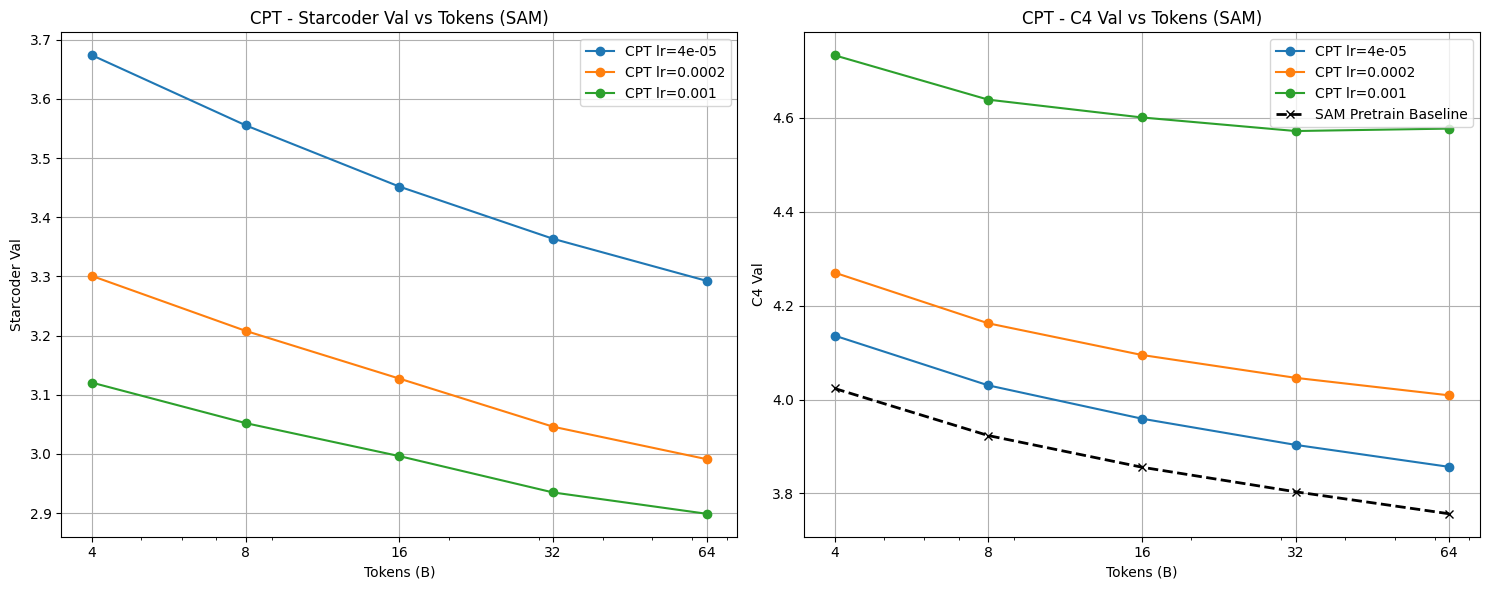

In [133]:
import matplotlib.pyplot as plt

tokens_list = [4, 8, 16, 32, 64]

# Get CPT runs from sam-ablation for SAM optimizer
sam_cpt_runs = [r for r in RESULTS["sam-ablation"] 
                if r.get("run_type") == "cpt" 
                and r.get("token") in tokens_list 
                and r.get("optimizer") == "sam"
                and r.get("base_optimizer") == "adamw"
                and r.get("rho") == 0.05]

# Get pretrain runs for SAM baseline with same criteria
sam_pretrain_runs = [r for r in RESULTS["sam-ablation"] 
                     if r.get("run_type") == "pretrain" 
                     and r.get("token") in tokens_list 
                     and r.get("optimizer") == "sam"
                     and r.get("base_optimizer") == "adamw"
                     and r.get("rho") == 0.05]

print(sam_cpt_runs)

# Get unique CPT learning rates
cpt_lrs = sorted(list(set([r.get("cpt_lr") for r in sam_cpt_runs if r.get("cpt_lr") is not None])))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Starcoder validation values
for lr in cpt_lrs:
    starcoder_points = []
    for t in tokens_list:
        candidates = [r for r in sam_cpt_runs 
                     if r.get("token") == t and r.get("cpt_lr") == lr]
        if candidates:
            # Pick the one with the best (lowest) starcoder_val
            best = min(candidates, key=lambda x: x.get("starcoder_val", float('inf')))
            starcoder_points.append((t, best["starcoder_val"]))
        else:
            starcoder_points.append((t, None))
    
    starcoder_tokens, starcoder_vals = zip(*[(t, v) for t, v in starcoder_points if v is not None])
    if starcoder_tokens:
        ax1.plot(starcoder_tokens, starcoder_vals, marker='o', label=f'CPT lr={lr}')

ax1.set_xscale('log')
ax1.set_xticks(tokens_list)
ax1.set_xticklabels(tokens_list)
ax1.set_xlabel("Tokens (B)")
ax1.set_ylabel("Starcoder Val")
ax1.set_title("CPT - Starcoder Val vs Tokens (SAM)")
ax1.legend()
ax1.grid(True)

# Plot 2: C4 validation values with SAM baseline
for lr in cpt_lrs:
    c4_points = []
    for t in tokens_list:
        candidates = [r for r in sam_cpt_runs 
                     if r.get("token") == t and r.get("cpt_lr") == lr]
        if candidates:
            # Pick the one with the best (lowest) c4_val
            best = min(candidates, key=lambda x: x.get("c4_val", float('inf')))
            c4_points.append((t, best["c4_val"]))
        else:
            c4_points.append((t, None))
    
    c4_tokens, c4_vals = zip(*[(t, v) for t, v in c4_points if v is not None])
    if c4_tokens:
        ax2.plot(c4_tokens, c4_vals, marker='o', label=f'CPT lr={lr}')

# Add SAM baseline pretrain results
baseline_points = []
for t in tokens_list:
    candidates = [r for r in sam_pretrain_runs if r.get("token") == t]
    if candidates:
        best = min(candidates, key=lambda x: x.get("c4_val", float('inf')))
        baseline_points.append((t, best["c4_val"]))
    else:
        baseline_points.append((t, None))

baseline_tokens, baseline_vals = zip(*[(t, v) for t, v in baseline_points if v is not None])
if baseline_tokens:
    ax2.plot(baseline_tokens, baseline_vals, marker='x', linestyle='--', 
             color='black', linewidth=2, label='SAM Pretrain Baseline')

ax2.set_xscale('log')
ax2.set_xticks(tokens_list)
ax2.set_xticklabels(tokens_list)
ax2.set_xlabel("Tokens (B)")
ax2.set_ylabel("C4 Val")
ax2.set_title("CPT - C4 Val vs Tokens (SAM)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

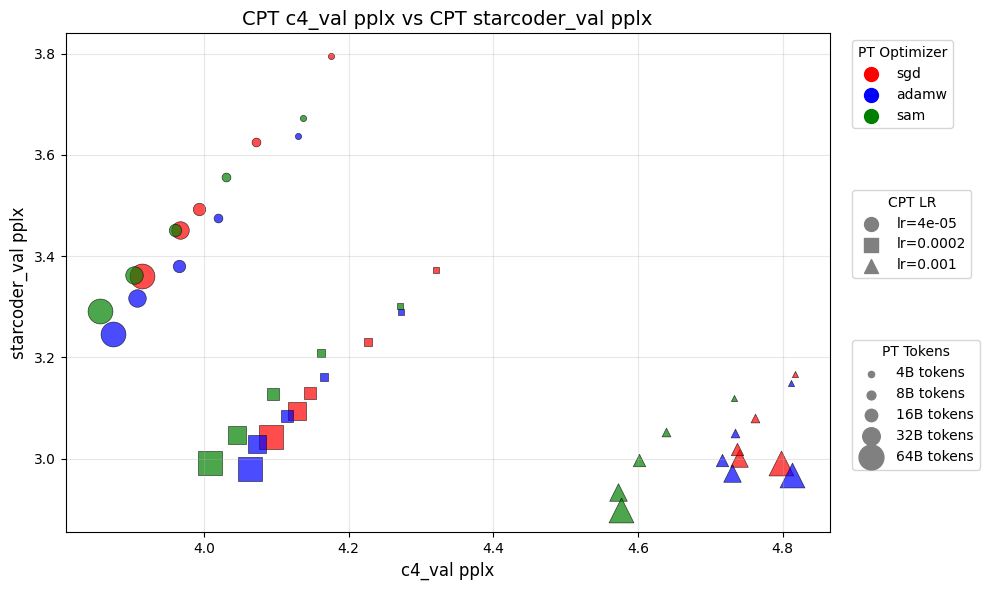

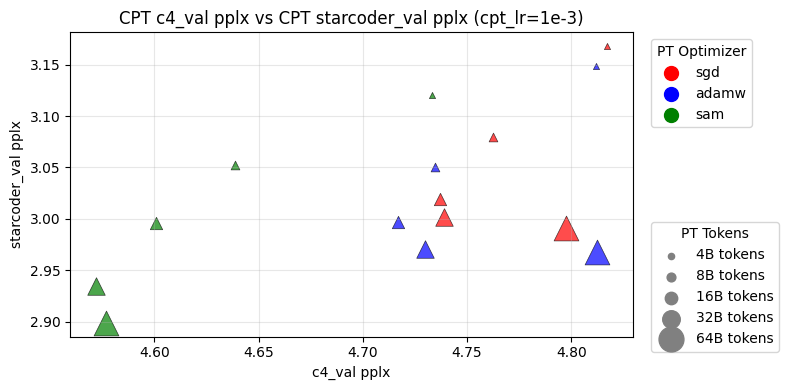

In [64]:
tokens_list = [4, 8, 16, 32, 64]

# Collect all CPT runs from different sources
all_cpt_runs = []

# SGD runs from sgd-gridsearch
sgd_cpt_runs = []
for r in RESULTS["sgd-gridsearch"]:
    if (
        r.get("run_type") == "cpt"
        and r.get("token") in tokens_list
        and r.get("optimizer") == "sgd"
        and float(r.get("pretrain_wd", -1)) == 1e-5
    ):
        token = r.get("token")
        pretrain_lr = float(r.get("pretrain_lr", -1))
        # For 64 tokens, use lr=0.5; for 4,8,16,32 use lr=1.0
        if (token == 64 and pretrain_lr == 0.5) or (token != 64 and pretrain_lr == 1.0):
            sgd_cpt_runs.append(r)
for run in sgd_cpt_runs:
    run['source_optimizer'] = 'sgd'
all_cpt_runs.extend(sgd_cpt_runs)

# AdamW runs from sgd-gridsearch  
adamw_cpt_runs = [r for r in RESULTS["sgd-gridsearch"] 
                  if r.get("run_type") == "cpt" 
                  and r.get("token") in tokens_list 
                  and r.get("optimizer") == "adamw"]
for run in adamw_cpt_runs:
    run['source_optimizer'] = 'adamw'
all_cpt_runs.extend(adamw_cpt_runs)

# AdamW runs from sgd-gridsearch  
# lionw_cpt_runs = [r for r in RESULTS["sgd-gridsearch"] 
#                   if r.get("run_type") == "cpt" 
#                   and r.get("token") in tokens_list 
#                   and r.get("optimizer") == "lionw"]
# for run in lionw_cpt_runs:
#     run['source_optimizer'] = 'lionw'
# all_cpt_runs.extend(lionw_cpt_runs)

# SAM runs from sam-ablation
sam_cpt_runs = [r for r in RESULTS["sam-ablation"] 
                if r.get("run_type") == "cpt" 
                and r.get("token") in tokens_list 
                and r.get("optimizer") == "sam"
                and r.get("base_optimizer") == "adamw"
                and r.get("rho") == 0.05]
for run in sam_cpt_runs:
    run['source_optimizer'] = 'sam'
all_cpt_runs.extend(sam_cpt_runs)

# Get unique CPT learning rates and tokens for markers and sizes
cpt_lrs = sorted(list(set([r.get("cpt_lr") for r in all_cpt_runs if r.get("cpt_lr") is not None])))
optimizers = ['sgd', 'adamw', 'sam']

# Define colors for optimizers
optimizer_colors = {'sgd': 'red', 'adamw': 'blue', 'sam': 'green'}

# Define markers for CPT learning rates
lr_markers = {}
marker_styles = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
for i, lr in enumerate(cpt_lrs):
    lr_markers[lr] = marker_styles[i % len(marker_styles)]

# Define sizes for tokens (proportional to token count)
token_sizes = {4: 20, 8: 40, 16: 80, 32: 160, 64: 320}

# ------------ FIRST PLOT: all lr (as before) ------------

plt.figure(figsize=(10, 6))

# Plot each run
for run in all_cpt_runs:
    if run.get("c4_val") is not None and run.get("starcoder_val") is not None:
        optimizer = run['source_optimizer']
        cpt_lr = run.get("cpt_lr")
        token = run.get("token")
        
        plt.scatter(run["c4_val"], run["starcoder_val"], 
                   color=optimizer_colors[optimizer],
                   marker=lr_markers[cpt_lr],
                   s=token_sizes[token],
                   alpha=0.7,
                   edgecolors='black',
                   linewidth=0.5)

plt.xlabel("c4_val pplx", fontsize=12)
plt.ylabel("starcoder_val pplx", fontsize=12)
plt.title("CPT c4_val pplx vs CPT starcoder_val pplx", fontsize=14)
plt.grid(True, alpha=0.3)

# Create legends
# Legend for optimizers (colors)
optimizer_handles = []
for opt in optimizers:
    optimizer_handles.append(plt.scatter([], [], color=optimizer_colors[opt], 
                                       marker='o', s=100, label=f'{opt}'))

# Legend for CPT learning rates (markers)
lr_handles = []
for lr in cpt_lrs:
    lr_handles.append(plt.scatter([], [], color='gray', 
                                marker=lr_markers[lr], s=100, label=f'lr={lr}'))

# Legend for token sizes
token_handles = []
for token in tokens_list:
    token_handles.append(plt.scatter([], [], color='gray', marker='o', 
                                   s=token_sizes[token], label=f'{token}B tokens'))

# Create multiple legends
optimizer_legend = plt.legend(handles=optimizer_handles, title="PT Optimizer", 
                            loc='upper left', bbox_to_anchor=(1.02, 1))
plt.gca().add_artist(optimizer_legend)

lr_legend = plt.legend(handles=lr_handles, title="CPT LR", 
                      loc='upper left', bbox_to_anchor=(1.02, 0.7))
plt.gca().add_artist(lr_legend)

token_legend = plt.legend(handles=token_handles, title="PT Tokens", 
                         loc='upper left', bbox_to_anchor=(1.02, 0.4))

plt.tight_layout()
plt.savefig(os.path.join(results_dir, f"optim_cpt_pplx.png"))
plt.show()


# ------------ SECOND PLOT: only cpt_lr == 1e-3 ------------

# First get 1e-3 marker and check float/str compatibility
cpt_lr_1e3 = None
for lr in cpt_lrs:
    try:
        if abs(float(lr) - 1e-3) < 1e-10:
            cpt_lr_1e3 = lr
            break
    except Exception:
        pass
if cpt_lr_1e3 is None:
    # Try alternative: match to string '0.001'
    for lr in cpt_lrs:
        if str(lr) == "0.001":
            cpt_lr_1e3 = lr
            break

if cpt_lr_1e3 is not None:
    plt.figure(figsize=(8, 4))
    # Only runs with cpt_lr == 1e-3
    runs_1e3 = [run for run in all_cpt_runs if run.get("cpt_lr") == cpt_lr_1e3 and run.get("c4_val") is not None and run.get("starcoder_val") is not None]
    # For markers/legend, restrict to cpt_lr_1e3 only
    # The plot will have all optimizers and all tokens, as before

    for run in runs_1e3:
        optimizer = run['source_optimizer']
        token = run.get("token")
        plt.scatter(run["c4_val"], run["starcoder_val"],
                   color=optimizer_colors[optimizer],
                   marker=lr_markers[cpt_lr_1e3],
                   s=token_sizes[token],
                   alpha=0.7,
                   edgecolors='black',
                   linewidth=0.5)

    plt.xlabel("c4_val pplx")
    plt.ylabel("starcoder_val pplx")
    plt.title("CPT c4_val pplx vs CPT starcoder_val pplx (cpt_lr=1e-3)")
    plt.grid(True, alpha=0.3)

    # Legend for optimizers (colors)
    optimizer_handles = []
    for opt in optimizers:
        optimizer_handles.append(plt.scatter([], [], color=optimizer_colors[opt], 
                                             marker='o', s=100, label=f'{opt}'))
    # Single lr marker for cpt_lr=1e-3
    lr_handles = [plt.scatter([], [], color='gray', 
                             marker=lr_markers[cpt_lr_1e3], s=100, label=f'lr={cpt_lr_1e3}')]
    # Legend for token sizes
    token_handles = []
    for token in tokens_list:
        token_handles.append(plt.scatter([], [], color='gray', marker='o', 
                                       s=token_sizes[token], label=f'{token}B tokens'))

    optimizer_legend = plt.legend(handles=optimizer_handles, title="PT Optimizer", 
                                loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.gca().add_artist(optimizer_legend)

    # lr_legend = plt.legend(handles=lr_handles, title="CPT LR", 
    #                       loc='upper left', bbox_to_anchor=(1.02, 0.7))
    # plt.gca().add_artist(lr_legend)

    token_legend = plt.legend(handles=token_handles, title="PT Tokens", 
                             loc='upper left', bbox_to_anchor=(1.02, 0.4))

    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, f"optim_cpt_pplx_lr1e-3.png"))
    plt.show()
else:
    print("No runs with cpt_lr = 1e-3 found. Skipping second plot.")

In [12]:
files = dict()
files["pretrain"] = []
files["cpt"] = []

for file in os.listdir(results_dir):
    if "CPT" in file:
        files["cpt"].append(os.path.join(results_dir, file))
    else:
        files["pretrain"].append(os.path.join(results_dir, file))

In [ ]:
import re

def scientific_to_decimal(s):
    """Convert a sci-notation string like '5e-2', '5e-2-', '5e-2-e', or '5e-2-e-' to a decimal string '0.05'."""
    if s == "unknown":
        return s
    # First, remove any '-e' or '-e-' at the end (to cover e.g. '5e-2-e' and '5e-2-e-')
    s = re.sub(r'(-e-?|(-e)?-)$', '', s)
    # Remove trailing non-alphanumerics (e.g. '-' or other chars after number)
    s = re.sub(r'[^0-9eE\+\-\.]+$', '', s)
    while s.endswith('-'):
        s = s[:-1]
    try:
        return str(float(s))
    except Exception:
        return s  # Return as is if conversion fails

def extract_pretrain_info(filename):
    d = {}
    if "sam" in filename:
        d["type"] = "sam"
        m = re.search(r"-rho([0-9eE\+\-\.e\-]*)", filename)
        if m:
            d["rho"] = scientific_to_decimal(m.group(1))
        else:
            d["rho"] = "unknown"
    elif "sgd" in filename:
        d["type"] = "sgd"
    else:
        d["type"] = "unknown"
    return d

def extract_cpt_info(filename):
    d = {}
    if "sam" in filename:
        d["type"] = "sam"
        m = re.search(r"-rho([0-9eE\+\-\.e\-]*)", filename)
        if m:
            d["rho"] = scientific_to_decimal(m.group(1))
        else:
            d["rho"] = "unknown"
    elif "sgd" in filename:
        d["type"] = "sgd"
    else:
        d["type"] = "unknown"
    m = re.search(r"-CPT-starcoder-lr([0-9eE\+\-\.e\-]*)", filename)
    if m:
        d["lr"] = scientific_to_decimal(m.group(1))
    else:
        d["lr"] = "unknown"
    return d

def find_metric_value(data, name):
    # Check for keys containing the task name, e.g. "c4" or "starcoder"
    for k, v in data.items():
        if name in k:
            # round to 3 decimal places if value is a float
            if isinstance(v, float):
                return round(v, 3)
            else:
                return v
    return None

results_by_group = {"pretrain": {}, "cpt": {}}

for group in ["pretrain", "cpt"]:
    for file in files[group]:
        with open(file, "r") as f:
            data = json.load(f)
        bn = os.path.basename(file)
        if group == "pretrain":
            info = extract_pretrain_info(bn)
            if info["type"] == "sam":
                rho = info["rho"]
                if "sam" not in results_by_group["pretrain"]:
                    results_by_group["pretrain"]["sam"] = {}
                if rho not in results_by_group["pretrain"]["sam"]:
                    results_by_group["pretrain"]["sam"][rho] = {}
                results_by_group["pretrain"]["sam"][rho]["c4"] = find_metric_value(data, "c4")
                results_by_group["pretrain"]["sam"][rho]["starcoder"] = find_metric_value(data, "starcoder")
            elif info["type"] == "sgd":
                if "sgd" not in results_by_group["pretrain"]:
                    results_by_group["pretrain"]["sgd"] = {}
                results_by_group["pretrain"]["sgd"]["c4"] = find_metric_value(data, "c4")
                results_by_group["pretrain"]["sgd"]["starcoder"] = find_metric_value(data, "starcoder")
        elif group == "cpt":
            info = extract_cpt_info(bn)
            if info["type"] == "sam":
                rho = info["rho"]
                lr = info["lr"]
                if "sam" not in results_by_group["cpt"]:
                    results_by_group["cpt"]["sam"] = {}
                if rho not in results_by_group["cpt"]["sam"]:
                    results_by_group["cpt"]["sam"][rho] = {}
                if lr not in results_by_group["cpt"]["sam"][rho]:
                    results_by_group["cpt"]["sam"][rho][lr] = {}
                results_by_group["cpt"]["sam"][rho][lr]["c4"] = find_metric_value(data, "c4")
                results_by_group["cpt"]["sam"][rho][lr]["starcoder"] = find_metric_value(data, "starcoder")
            elif info["type"] == "sgd":
                lr = info["lr"]
                if "sgd" not in results_by_group["cpt"]:
                    results_by_group["cpt"]["sgd"] = {}
                if lr not in results_by_group["cpt"]["sgd"]:
                    results_by_group["cpt"]["sgd"][lr] = {}
                results_by_group["cpt"]["sgd"][lr]["c4"] = find_metric_value(data, "c4")
                results_by_group["cpt"]["sgd"][lr]["starcoder"] = find_metric_value(data, "starcoder")


In [52]:
results_by_group["cpt"]

{'sam': {'0.01': {'0.001': {'c4': 6.77, 'starcoder': 5.306},
   '0.0002': {'c4': 7.136, 'starcoder': 6.715},
   '4e-05': {'c4': 7.278, 'starcoder': 8.038}},
  '0.1': {'0.001': {'c4': 6.846, 'starcoder': 5.384},
   '4e-05': {'c4': 7.425, 'starcoder': 8.12},
   '0.0002': {'c4': 7.232, 'starcoder': 6.784}},
  '0.05': {'4e-05': {'c4': 7.334, 'starcoder': 8.085},
   '0.0002': {'c4': 7.164, 'starcoder': 6.763},
   '0.001': {'c4': 6.798, 'starcoder': 5.344}},
  '0.0': {'0.0002': {'c4': 7.126, 'starcoder': 6.706},
   '4e-05': {'c4': 7.268, 'starcoder': 8.029},
   '0.001': {'c4': 6.794, 'starcoder': 5.339}},
  '0.02': {'4e-05': {'c4': 7.291, 'starcoder': 8.049},
   '0.001': {'c4': 6.782, 'starcoder': 5.313},
   '0.0002': {'c4': 7.144, 'starcoder': 6.729}}},
 'sgd': {'0.001': {'c4': 6.794, 'starcoder': 5.339},
  '0.0002': {'c4': 7.126, 'starcoder': 6.706},
  '4e-05': {'c4': 7.268, 'starcoder': 8.029}}}

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --------- Prepare results_dir/plots output folder ---------
plots_dir = os.path.join(results_dir, "plots")
os.makedirs(plots_dir, exist_ok=True)

# --------- Pretrain Plots (Side by Side for c4 and starcoder, SAM only, log scores) ---------

pretrain = results_by_group["pretrain"]
sam_pretrain = pretrain['sam']  # dict: rho -> {'c4': v, 'starcoder': v}

# Get sorted rho values (as float for better plotting)
rhos = sorted([float(rho) for rho in sam_pretrain.keys()])
rhos_str = [str(rho) for rho in rhos]

c4_scores = [sam_pretrain[str(rho)]['c4'] for rho in rhos]
sc_scores = [sam_pretrain[str(rho)]['starcoder'] for rho in rhos]

log_c4_scores = np.log(c4_scores)
log_sc_scores = np.log(sc_scores)

fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
# c4 subplot
axs[0].plot(rhos, log_c4_scores, marker='o', color='tab:blue')
axs[0].set_xlabel("rho")
axs[0].set_ylabel("Log Perplexity")
axs[0].set_title("Pretrain: Log Perplexity C4 vs Rho (SAM)")
axs[0].grid(True)

# starcoder subplot
axs[1].plot(rhos, log_sc_scores, marker='s', color='tab:orange')
axs[1].set_xlabel("rho")
axs[1].set_ylabel("Log Perplexity")
axs[1].set_title("Pretrain: Log Perplexity Starcoder vs Rho (SAM)")
axs[1].grid(True)

plt.tight_layout()
fname = os.path.join(plots_dir, "pretrain_log_perplexity_c4_and_starcoder_vs_rho_sam.png")
plt.savefig(fname)
plt.close(fig)

# # --------- CPT Plots (Side by Side for c4 and starcoder, one for each lr), and one big plot with all lr, SAM only, log scores ---------

cpt = results_by_group["cpt"]
sam_cpt = cpt['sam'] # dict: rho -> lr -> {'c4': v, 'starcoder': v}

# List all unique learning rates present (order them for plotting)
lrs = sorted({float(lr) for rhos in sam_cpt.values() for lr in rhos})
lrs_str = [str(lr) for lr in lrs]

# # Side by side individual plots for each lr
for lr in lrs_str:
    rhos_with_lr = []
    c4_scores = []
    sc_scores = []
    for rho in sam_cpt:
        if lr in sam_cpt[rho]:
            rhos_with_lr.append(float(rho))
            c4_scores.append(sam_cpt[rho][lr]['c4'])
            sc_scores.append(sam_cpt[rho][lr]['starcoder'])
    if rhos_with_lr:
        order = sorted(range(len(rhos_with_lr)), key=lambda i: rhos_with_lr[i])
        rhos_sorted = [rhos_with_lr[i] for i in order]
        c4_sorted = [c4_scores[i] for i in order]
        sc_sorted = [sc_scores[i] for i in order]
        log_c4_sorted = np.log(c4_sorted)
        log_sc_sorted = np.log(sc_sorted)
        fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
        # c4 subplot
        axs[0].plot(rhos_sorted, log_c4_sorted, marker='o', color='tab:blue')
        axs[0].set_xlabel("Rho")
        axs[0].set_ylabel("Log Perplexity")
        axs[0].set_title(f"CPT: Log Perplexity C4 vs Rho (SAM), lr={lr}")
        axs[0].legend()
        axs[0].grid(True)

        # starcoder subplot
        axs[1].plot(rhos_sorted, log_sc_sorted, marker='s', color='tab:orange')
        axs[1].set_xlabel("Rho")
        axs[1].set_ylabel("Log Perplexity")
        axs[1].set_title(f"CPT: Log Perplexity Starcoder vs Rho (SAM), lr={lr}")
        axs[1].legend()
        axs[1].grid(True)

        plt.tight_layout()
        fname = os.path.join(plots_dir, f"cpt_log_perplexity_c4_and_starcoder_vs_rho_sam_lr{lr}.png")
        plt.savefig(fname)
        plt.close(fig)

# --------- Single combined CPT Plot: All 3 lr for both c4 and starcoder, SAM only, log scores ---------

# c4
fig_c4, ax_c4 = plt.subplots(figsize=(8,5))
for idx, lr in enumerate(lrs_str):
    rhos_with_lr = []
    c4_scores = []
    for rho in sam_cpt:
        if lr in sam_cpt[rho]:
            rhos_with_lr.append(float(rho))
            c4_scores.append(sam_cpt[rho][lr]['c4'])
    if rhos_with_lr:
        order = sorted(range(len(rhos_with_lr)), key=lambda i: rhos_with_lr[i])
        rhos_sorted = [rhos_with_lr[i] for i in order]
        c4_sorted = [c4_scores[i] for i in order]
        log_c4_sorted = np.log(c4_sorted)
        ax_c4.plot(rhos_sorted, log_c4_sorted, marker='o', label=f'lr={lr}')
ax_c4.set_xlabel("Rho")
ax_c4.set_ylabel("Log Perplexity")
ax_c4.set_title("CPT: Log Perplexity C4 vs Rho for all lr (SAM)")
# ax_c4.legend()
ax_c4.grid(True)
plt.tight_layout()
fname_c4 = os.path.join(plots_dir, "cpt_log_perplexity_c4_vs_rho_all_lr_sam.png")
plt.savefig(fname_c4)
plt.close(fig_c4)

# starcoder
fig_sc, ax_sc = plt.subplots(figsize=(8,5))
for idx, lr in enumerate(lrs_str):
    rhos_with_lr = []
    sc_scores = []
    for rho in sam_cpt:
        if lr in sam_cpt[rho]:
            rhos_with_lr.append(float(rho))
            sc_scores.append(sam_cpt[rho][lr]['starcoder'])
    if rhos_with_lr:
        order = sorted(range(len(rhos_with_lr)), key=lambda i: rhos_with_lr[i])
        rhos_sorted = [rhos_with_lr[i] for i in order]
        sc_sorted = [sc_scores[i] for i in order]
        log_sc_sorted = np.log(sc_sorted)
        ax_sc.plot(rhos_sorted, log_sc_sorted, marker='s', label=f'lr={lr}')
ax_sc.set_xlabel("Rho")
ax_sc.set_ylabel("Log Perplexity")
ax_sc.set_title("CPT: Log Perplexity Starcoder vs Rho for all lr (SAM)")
ax_sc.legend()
ax_sc.grid(True)
plt.tight_layout()
fname_sc = os.path.join(plots_dir, "cpt_log_perplexity_starcoder_vs_rho_all_lr_sam.png")
plt.savefig(fname_sc)
plt.close(fig_sc)


/mnt/tmp/2719300/ipykernel_495235/922332008.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()
/mnt/tmp/2719300/ipykernel_495235/922332008.py:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


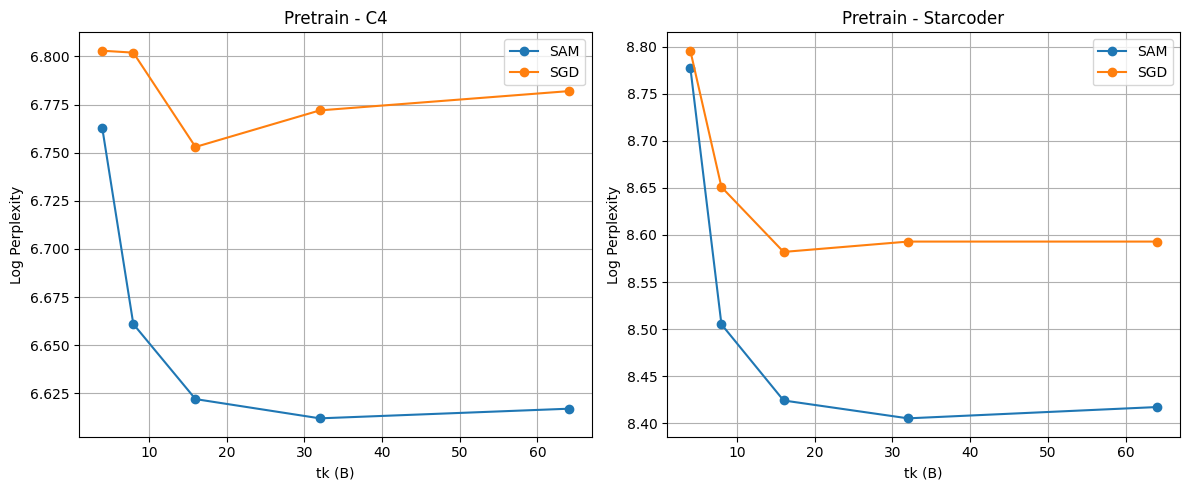

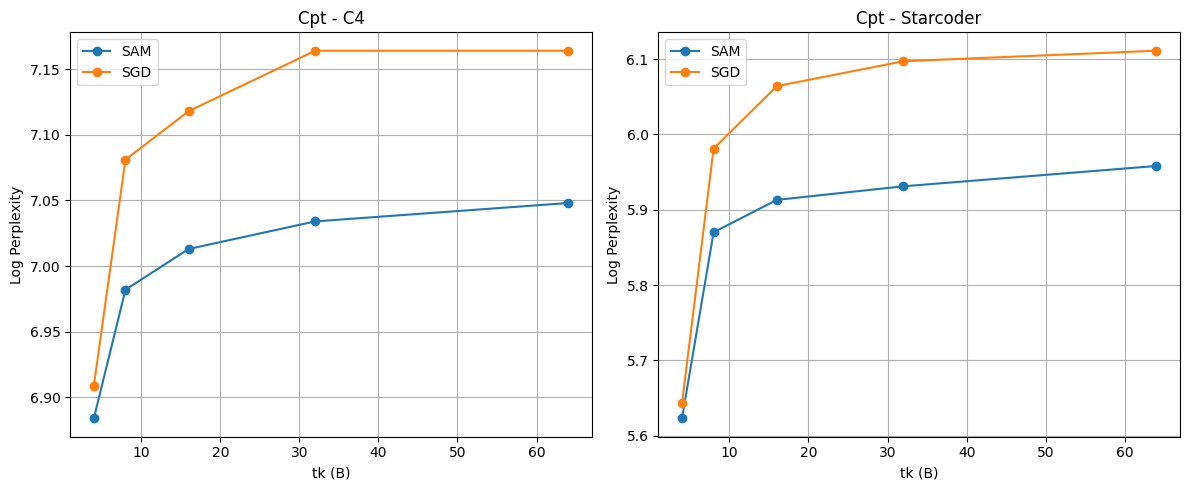

In [4]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt

eval_dir = "results/sam-overtraining/ModelEvaluation"
files = glob.glob(os.path.join(eval_dir, "*.json"))

# Helper to extract info from filenames
def parse_filename(fname):
    f = os.path.basename(fname)
    group = "pretrain" if "CPT" not in f else "cpt"
    # tk extraction
    tk = None
    import re
    tk_match = re.search(r'tk(\d+)B', f)
    if tk_match:
        tk = tk_match.group(1)
    # optimizer
    optimizer = None
    if '-sam-' in f:
        optimizer = "sam"
    elif '-sgd-' in f:
        optimizer = "sgd"
    return group, tk, optimizer

# Metric json keys
c4_key = "eval-data_perplexity_v3_small_gptneox20b_c4_en_val_part-0-00000"
starcoder_key = "preprocessed_starcoder_v0_decontaminated_doc_only_gpt-neox-olmo-dolma-v1_5_part-00-00001"

# Collect results
results_unsorted = {
    "pretrain": {},
    "cpt": {},
}
# results[group][optimizer] = {"c4": val, "starcoder": val}

for file in files:
    group, tk, optimizer = parse_filename(file)
    if optimizer is None or tk is None:
        continue
    with open(file, "r") as f:
        j = json.load(f)
    c4_val = float(j.get(c4_key, np.nan))
    star_val = float(j.get(starcoder_key, np.nan))
    if optimizer not in results_unsorted[group]:
        results_unsorted[group][optimizer] = {}
    # Store as (tk, log_pplx)
    results_unsorted[group][optimizer][tk] = {
        "c4": round(c4_val, 3) if not np.isnan(c4_val) else np.nan,
        "starcoder": round(star_val, 3) if not np.isnan(star_val) else np.nan,
    }

# Now, sort the tk subdicts by integer value of tk (4, 8, 16...)
def sort_results_by_tk(results_dict):
    sorted_results = {}
    for group in results_dict:
        sorted_results[group] = {}
        for optimizer in results_dict[group]:
            # sort by integer conversion of tk keys
            tk_items = list(results_dict[group][optimizer].items())
            tk_items_sorted = sorted(tk_items, key=lambda x: int(x[0]))
            sorted_results[group][optimizer] = {tk: v for tk, v in tk_items_sorted}
    return sorted_results

results = sort_results_by_tk(results_unsorted)

# Plotting function: side by side c4 and starcoder for a group
def plot_pretrain_cpt(results_for_group, groupname, plots_dir="."):
    opts = sorted(results_for_group)
    fig, axs = plt.subplots(1, 2, figsize=(12,5))
    for i, key in enumerate(["c4", "starcoder"]):
        for optimizer in opts:
            # Sort tks by integer value
            tks = sorted(results_for_group[optimizer], key=lambda x: int(x))
            y = [
                results_for_group[optimizer][tk][key]
                for tk in tks
                if key in results_for_group[optimizer][tk]
            ]
            x = [int(tk) for tk in tks]
            axs[i].plot(x, y, marker='o', label=optimizer.upper())
        axs[i].set_xlabel("tk (B)")
        axs[i].set_ylabel("Log Perplexity")
        axs[i].set_title(f"{groupname.capitalize()} - {key.capitalize()}")
        axs[i].legend()
        axs[i].grid(True)
    plt.tight_layout()
    fname = os.path.join(plots_dir, f"{groupname}_log_perplexity_sam_vs_sgd.png")
    plt.savefig(fname)
    plt.show()
    plt.close(fig)

plots_dir = "plots"
os.makedirs(plots_dir, exist_ok=True)
if results["pretrain"]:
    plot_pretrain_cpt(results["pretrain"], "pretrain", plots_dir)
if results["cpt"]:
    plot_pretrain_cpt(results["cpt"], "cpt", plots_dir)


In [2]:
results

{'pretrain': {'sgd': {'16': {'c4': 1.91, 'starcoder': 2.15},
   '4': {'c4': 1.917, 'starcoder': 2.174},
   '64': {'c4': 1.914, 'starcoder': 2.151},
   '32': {'c4': 1.913, 'starcoder': 2.151},
   '8': {'c4': 1.917, 'starcoder': 2.158}},
  'sam': {'4': {'c4': 1.911, 'starcoder': 2.172},
   '16': {'c4': 1.89, 'starcoder': 2.131},
   '8': {'c4': 1.896, 'starcoder': 2.141},
   '32': {'c4': 1.889, 'starcoder': 2.129},
   '64': {'c4': 1.89, 'starcoder': 2.13}}},
 'cpt': {'sam': {'16': {'c4': 1.948, 'starcoder': 1.777},
   '32': {'c4': 1.951, 'starcoder': 1.78},
   '64': {'c4': 1.953, 'starcoder': 1.785},
   '8': {'c4': 1.943, 'starcoder': 1.77},
   '4': {'c4': 1.929, 'starcoder': 1.727}},
  'sgd': {'16': {'c4': 1.963, 'starcoder': 1.802},
   '8': {'c4': 1.957, 'starcoder': 1.789},
   '4': {'c4': 1.933, 'starcoder': 1.73},
   '64': {'c4': 1.969, 'starcoder': 1.81},
   '32': {'c4': 1.969, 'starcoder': 1.808}}}}